In [39]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.utils.data as data
import torchvision.transforms.v2 as tfs

import os
import json
from PIL import Image

from tqdm import tqdm

import matplotlib.pyplot as plt

### Класс для загрузки датасета

In [2]:
class DigitDataset(data.Dataset):
    def __init__(self, path, train=True, transform=None):
        self.path = os.path.join(path, "train" if train else "test")
        self.transform = transform

        with open(os.path.join(path, "format.json"), "r") as file:
            self.format = json.load(file)
        
        self.files = []
        self.length = 0
        self.targets = torch.eye(10)

        for dir_, target_ in self.format.items():
            cl_path = os.path.join(self.path, dir_)
            list_filenames = os.listdir(cl_path)
            self.length += len(list_filenames)
            self.files.extend(map(lambda x_: (os.path.join(cl_path, x_), target_), list_filenames))

    def __getitem__(self, item):
        img_path, target = self.files[item]
        img_pil = Image.open(img_path)

        if self.transform:
            img_tensor = self.transform(img_pil).ravel().float() / 255.
        
        return img_tensor, self.targets[target]

    def __len__(self):
        return self.length

In [3]:
to_tensor = tfs.ToImage()
all_data = DigitDataset(path=f"/Users/sidorovegor/Desktop/projects/python/dl_selfedu_course/datasets/dataset_MNIST", train=True, transform=to_tensor)

In [4]:
d_train, d_val = data.random_split(all_data, [0.7, 0.3])
train_data = data.DataLoader(d_train, batch_size=32, shuffle=True)
val_data = data.DataLoader(d_val, batch_size=32, shuffle=False)

### Проверка работы написанного класса

In [5]:
it = iter(train_data)
x, y = next(it)
x.shape, y.shape

(torch.Size([32, 784]), torch.Size([32, 10]))

### Класс с моделью для классификации

In [32]:
class DigitNN(nn.Module):
    def __init__(self, inp, hid, out):
        super().__init__()
        self.l1 = nn.Linear(inp, hid)
        self.l2 = nn.Linear(hid, out)

    def forward(self, x):
        x = self.l1(x).relu()
        x = self.l2(x)

        return x

In [33]:
model = DigitNN(28 * 28, 32, 10)

In [34]:
optimizer = optim.Adam(params=model.parameters(), lr=0.01)
loss_func = nn.CrossEntropyLoss()

In [35]:
train_means = []
val_means = []

In [ ]:
best_loss = 1e10 # заведомо большое значение

epochs = 5
for _e in range(epochs):
    model.train()
    
    train_bar = tqdm(train_data, leave=False) # leave = True - чтобы прогресс оставался на экране

    loss_mean = 0
    lm_count = 0

    for x_train, y_train in train_bar:
        pred = model(x_train)
        loss = loss_func(pred, y_train)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        lm_count += 1
        loss_mean = 1 / lm_count * loss.item() + (1 - 1 / lm_count) * loss_mean

        train_bar.set_description(f"Epoch [{_e + 1}/{epochs}] training, loss_mean={loss_mean:.3f}:")

    if best_loss > loss_mean * 1.1:
        best_loss = loss_mean
        st = model.state_dict()
        torch.save(st, f"weights/train_MNIST/MNIST_epoch{_e}.tar")

    model.eval()
    Q_val = 0
    Q_count = 0

    val_bar = tqdm(val_data, leave=False)

    for x_val, y_val in val_bar:
        with torch.no_grad():
            pred = model(x_val)
            Q_val += loss_func(pred, y_val).item()
            Q_count += 1

            val_bar.set_description(f"Epoch [{_e + 1}/{epochs}] validation, loss_mean={Q_val/Q_count:.3f}:")
    Q_val /= Q_count

    train_means += [loss_mean]
    val_means += [Q_val]

    print(f"Epoch [{_e + 1}/{epochs}], loss_trin={loss_mean:.3f}, loss__val={Q_val:.3f}")

Epoch [1/5], loss_trin=0.308, loss__val=0.221


Epoch [2/5], loss_trin=0.198, loss__val=0.220


Epoch [3/5], loss_trin=0.178, loss__val=0.238


Epoch [4/5], loss_trin=0.167, loss__val=0.190


Epoch [5/5], loss_trin=0.158, loss__val=0.215


In [37]:
d_test = DigitDataset(path=f"/Users/sidorovegor/Desktop/projects/python/dl_selfedu_course/datasets/dataset_MNIST", train=False, transform=to_tensor)
test_data = data.DataLoader(d_test, batch_size=500, shuffle=False)

In [38]:
Q = 0
model.eval()
for x_test, y_test in test_data:
    with torch.no_grad():
        pred = model(x_test)
        pred = torch.argmax(pred, dim=1)
        y = torch.argmax(y_test, dim=1)

        Q += (pred == y).sum().item()

Q /= len(d_test)
Q

0.9438

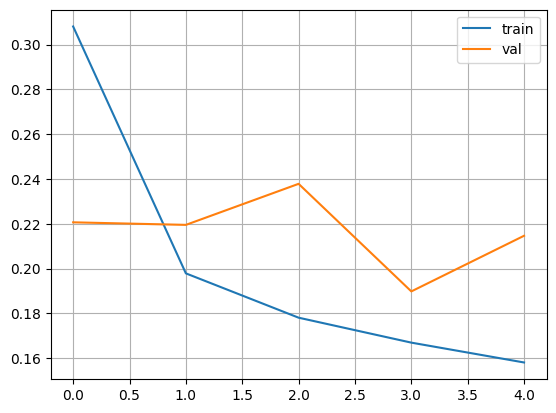

In [45]:
plt.plot(range(len(train_means)), train_means, label="train")
plt.plot(range(len(val_means)), val_means, label="val")
plt.grid(True)
plt.legend();

In [ ]:
x